
# ICS - Travaux Pratiques 10

07.05.25


<font color=grey>_Ce 10e TP se concentre sur les algorithmes permettant d'approximer les racines d'une fonction non linéaire en utilisant une approche dichotomique. Nous allons également étudier les différentes approximations possibles de la dérivée d'une fonction pour se préparer au cours de la semaine prochaine._ 

_Note : ne vous sentez pas obligé.e.s de finir la série pendant la séance! Celle-ci est conçue de manière à ce que vous gardiez certains exercices pour vos révisions._ </font>

***

## Exercice 0 : Echauffement

Soit la fonction réelle d'une variable réelle $g:\mathcal{R}\rightarrow\mathcal{R}$ définie par 

$$
g(x) = x^3 sin(\pi x)\,.
$$

On cherche à étudier la fonction $g$ en la représentant graphiquement et en déterminant en particulier le nombre de ses zéros dans un intervalle donné. Pour ce faire, il vous est demandé

1. d'implémenter une fonction Python `representation_graphique` admettant pour arguments :
  * une fonction `f` ;
  * deux nombres `a` et `b`, avec $b>a$, qui précisent, en abscisse, l'intervalle sur lequel la fonction doit être représentée ; 
  * le nombre `N` de points $(x,f(x))$ à considérer dans la représentation ;
  * le `titre` de la représentation ;

  Cette fonction doit produire une sauvegarde `FigureTP10ICS.pdf` de la figure au format pdf et doit afficher la figure dans le Jupyter Notebook ;

2. de définir en Python la fonction $g(x)$ définie ci-dessus ;
3. d'appeler la fonction `representation_graphique` de manière à représenter la fonction $g(x)$ dans l'intervalle $[-2.2,2.2]$ en utilisant $100$ points et en lui donnant pour titre "Représentation graphique de $g(x)$" ;
4. de déterminer visuellement le nombre de zéros dans l'intervalle considéré.

#### <font color=grey>Solution </font>

In [238]:
import numpy as np 
import matplotlib.pyplot as plt

# 1. Solution du point 1
def representation_graphique(f, a, b, N, titre):
    if b > a:
        x = np.linspace(a, b + (b-a)/N, N)
        g = f(x)
        
        plt.plot(x, g)
        plt.hlines(0, a, b, color="grey")
        plt.title(titre)
        
        plt.savefig("FigureTP10ICS.pdf", format="pdf")
        
        plt.show()
    else:
        print("Sussy baka !")

In [239]:
# 2. Solution du point 2
def g(x):
    return x ** 3 * np.sin(np.pi * x)

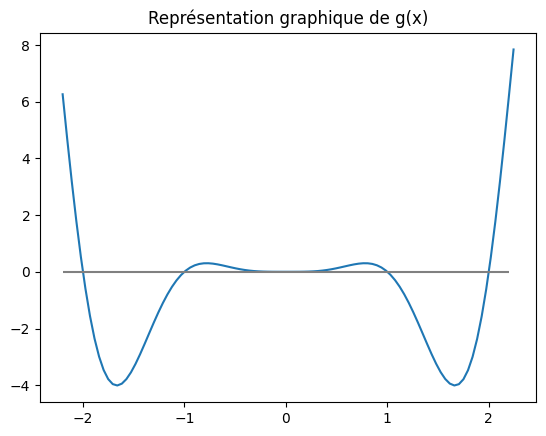

In [240]:
# 3. Solution du point 3
representation_graphique(g, -2.2, 2.2, 100, "Représentation graphique de g(x)") # nombre de zéros dans l'intervalle [-2.2, 2.2] : 5

***

## Exercice 1 : Méthode de bissection

Soit la fonction réelle d'une variable réelle $g(x)$ définie ci-dessus à l'`exercice 0`.

Il vous est demandé$\ldots$
1. en utilisant le **théorème de Bolzano**, de montrer que la fonction $g$ admet (au moins) un zéro dans l'intervalle $]-2,-\frac{1}{2}[$.
2. en implémentant l'algorithme correspondant à la **méthode de la bissection simple**, de trouver un zéro de $g$ appartenant à l'intervalle $]-2,-\frac{1}{2}[$ avec une **erreur (tolérance) inférieure à $10^{−8}$**.<br>
Construisez pour ce faire une fonction `resoudre_par_bissection_simple` ayant pour arguments :
    - la fonction `f` pour laquelle on veut trouver un zéro ;
    - les extrémités `a` et `b` de l'intervalle considéré ($a<b$) ;
    - la tolérance `tol` désirée.

   Cette fonction doit s'assurer que la condition de Bolzano est bien vérifiée pour l'intervalle demandé (et afficher un message d'erreur si ce n'est pas le cas) et doit retourner :
    - un nombre correspondant...
        * ... soit au point milieu du dernier intervalle considéré par la méthode,
        * ... soit au point milieu $m_k = (a_k + b_k)/2$ d'un intervalle vérifiant $f(m_k)=0$ (solution exacte),

   - ainsi qu'un nombre correspondant au nombre $k\ge 0$ d'itérations effectuées.

3. Au bout de combien d'itérations atteint-on la tolérance demandée? Montrez le résultat (i) théoriquement et (ii) numériquement.

4. Modifier votre fonction pour qu'elle retourne :
    - les solutions approximées $x_k$ à chaque itération de la méthode
    - la borne inférieure de l'intervalle à chaque itération $a_k$
    - la borne supérieure de l'intervalle à chaque itération $b_k$

5. La solution exacte de cette équation dans l'intervalle considéré vaut $\alpha=-1$. Représentez graphiquement l'évolution de l'erreur maximale entre la solution exacte et les bornes supérieures et inférieures des intervalles considérés max($\alpha-a_k, \alpha-b_k$) en fonction du nombre d'itérations. Représentez sur le même graphe l'erreur absolue pour chaque itération.


#### <font color=grey>Solution </font>

In [241]:
# 1. Solution du point 1
def theoreme_de_bolzano(f, a, b):
    if f(a)*f(b) < 0:
        return True 
    else:
        return False
    
    
theoreme_de_bolzano(g, -2, -.5)

True

In [242]:
# 2. Solution du point 2
class IntervalError(Exception):
    """Exception raised when there is no zero in the chosen interval."""
    
    def __init__(self, a, b):
        self.a = a
        self.b = b
        
    def __str__(self):
        return f"Dans l'intervalle [{self.a}, {self.b}], il n'y a pas de zéros !"
    
    def __repr__(self):
        return f"Dans l'intervalle [{self.a}, {self.b}], il n'y a pas de zéros !"


def resoudre_par_bissection_simple(f, a, b, tol):
    try:
        if a < b:
            if theoreme_de_bolzano(f, a, b):
                k = 1
                while (b-a)/(2**(k+1)) >= tol:
                    m_k = (b+a)/2
                    if f(a)*f(m_k) < 0:
                        b = m_k
                    elif f(m_k)*f(b) < 0:
                        a = m_k
                    elif f(m_k) == 0:
                        break
                    k += 1
                return f"m_k: {m_k}, i: {np.log2(np.abs(b-a) / (tol)) - 1}, ii: {k}, (b-a)/(2**(k+1)): {(b-a)/(2**(k+1))}"
            else:
                raise IntervalError(a, b)
    
    except IntervalError as e:
        print(e)
        
        
resoudre_par_bissection_simple(g, -2, -.5, 1e-08)

'm_k: -1.00006103515625, i: 13.160387259820055, ii: 14, (b-a)/(2**(k+1)): 5.587935447692871e-09'

In [243]:
# 4. Solution du point 4
def resoudre_par_bissection_simple_2(f, a, b, tol):
    try:
        if a < b:
            if theoreme_de_bolzano(f, a, b):
                k = 1
                x_k = []
                a_k = []
                b_k = []
                while (b-a)/(2**(k+1)) >= tol:
                    m_k = (b+a)/2
                    x_k.append(m_k)
                    a_k.append(a)
                    b_k.append(b)
                    
                    if f(a)*f(m_k) < 0:
                        b = m_k
                    elif f(m_k)*f(b) < 0:
                        a = m_k
                    elif f(m_k) == 0:
                        break
                    k += 1
                return f"x_k: {x_k}, a_k: {a_k}, b_k: {b_k}, m_k: {m_k}, \
                i: {np.log2(np.abs(b-a) / (tol)) - 1}, ii: {k}, \
                (b-a)/(2**(k+1)): (b-a)/(2**(k+1))"
            else:
                raise IntervalError(a, b)
    
    except IntervalError as e:
        print(e)
        
        
resoudre_par_bissection_simple_2(g, -2, -.5, 1e-08)

'x_k: [-1.25, -0.875, -1.0625, -0.96875, -1.015625, -0.9921875, -1.00390625, -0.998046875, -1.0009765625, -0.99951171875, -1.000244140625, -0.9998779296875, -1.00006103515625], a_k: [-2, -1.25, -1.25, -1.0625, -1.0625, -1.015625, -1.015625, -1.00390625, -1.00390625, -1.0009765625, -1.0009765625, -1.000244140625, -1.000244140625], b_k: [-0.5, -0.5, -0.875, -0.875, -0.96875, -0.96875, -0.9921875, -0.9921875, -0.998046875, -0.998046875, -0.99951171875, -0.99951171875, -0.9998779296875], m_k: -1.00006103515625,                 i: 13.160387259820055, ii: 14,                 (b-a)/(2**(k+1)): (b-a)/(2**(k+1))'

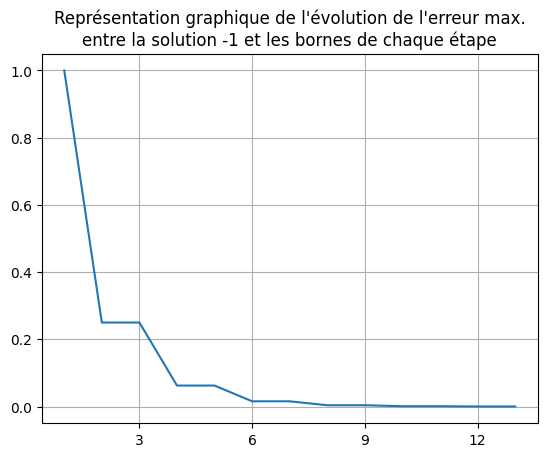

'x_k: [-1.25, -0.875, -1.0625, -0.96875, -1.015625, -0.9921875, -1.00390625, -0.998046875, -1.0009765625, -0.99951171875, -1.000244140625, -0.9998779296875, -1.00006103515625], a_k: [-2, -1.25, -1.25, -1.0625, -1.0625, -1.015625, -1.015625, -1.00390625, -1.00390625, -1.0009765625, -1.0009765625, -1.000244140625, -1.000244140625], b_k: [-0.5, -0.5, -0.875, -0.875, -0.96875, -0.96875, -0.9921875, -0.9921875, -0.998046875, -0.998046875, -0.99951171875, -0.99951171875, -0.9998779296875], m_k: -1.00006103515625,                 i: 13.160387259820055, ii: 14,                 (b-a)/(2**(k+1)): (b-a)/(2**(k+1))'

In [251]:
# 5. Solution du point 5
import matplotlib.ticker as ticker


def error_evolution(a, b, N, a_k, b_k, titre, alpha):
    if b > a:
        erreur_max = [max(alpha - a_k[i], alpha - b_k[i]) for i in range(len(a_k))]
        x = np.linspace(1, len(erreur_max), len(erreur_max))
        
        fig, ax = plt.subplots()
        
        ax.plot(x, erreur_max)
        ax.grid()
        plt.title(titre)
        ax.xaxis.set_major_locator(ticker.MaxNLocator(nbins=5))
        plt.show()
    else:
        print("Sussy baka !")
        
        
def resoudre_par_bissection_simple_3(f, a, b, tol, alpha):
    try:
        if a < b:
            if theoreme_de_bolzano(f, a, b):
                k = 1
                x_k = []
                a_k = []
                b_k = []
                while (b-a)/(2**(k+1)) >= tol:
                    m_k = (b+a)/2
                    x_k.append(m_k)
                    a_k.append(a)
                    b_k.append(b)
                    
                    if f(a)*f(m_k) < 0:
                        b = m_k
                    elif f(m_k)*f(b) < 0:
                        a = m_k
                    elif f(m_k) == 0:
                        break
                    k += 1
                    
                error_evolution(a, b, 100, a_k, b_k, f"Représentation graphique de l'évolution de l'erreur max.\n\
entre la solution {alpha} et les bornes de chaque étape", alpha)    
                
                return f"x_k: {x_k}, a_k: {a_k}, b_k: {b_k}, m_k: {m_k}, \
                i: {np.log2(np.abs(b-a) / (tol)) - 1}, ii: {k}, \
                (b-a)/(2**(k+1)): (b-a)/(2**(k+1))"
            else:
                raise IntervalError(a, b)
    
    except IntervalError as e:
        print(e)
        
        
resoudre_par_bissection_simple_3(g, -2, -.5, 1e-08, -1)

***

## Exercice 2 : Bissection par intervalles

Dans cet exercice, il vous est demandé d'utiliser la **méthode de la bissection par intervalles** pour déterminer une valeur approchée de **tous les zéros** dans l'intervalle $[-2.2,2.2]$ de la fonction 
$$
g(x) = x^3 sin(\pi x)
$$

déjà étudiée dans l'exercice précédent, l'**erreur commise** devant être inférieure à $10^{-8}$. Plus précisément, il vous est proposé de construire une nouvelle fonction `resoudre_par_bissection` qui fera appel à la fonction `resoudre_par_bissection_simple` définie dans la série précédente pour déterminer les zéros de $g$. Cette fonction devra admettre comme paramètres : 
* `f` : la fonction pour laquelle nous cherchons à trouver $\alpha$ tel que $f(\alpha)=0$ ;
* `a` et `b` : deux nombres qui correspondent aux bornes de l'intervalle initial de recherche ; 
* `step` : la longueur de chacun des intervalles considérés dans la méthode `resoudre_par_bissection_simple`;
* `tol` : nombre réel positif donnant la tolérance à atteindre.

La fonction doit retourner une liste `zeros` renfermant le(s) zéro(s).


Une représentation graphique de la fonction et des zéros trouvés vous permettra de vérifier votre implémentation.

Remarquons que les sous-intervalles peuvent être définis à l'aide d'un tableau (ndarray) de `numpy`, et qu'il faut être particulièrement vigilant dans le choix du nombre de sous-intervalles de manière à éviter la "perte" de certains zéros.

#### <font color=grey>Solution </font>

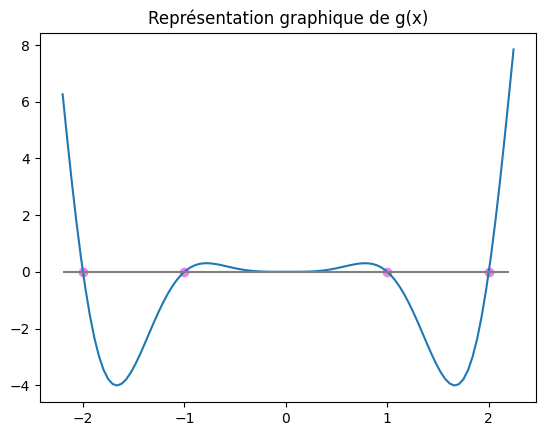

In [245]:
def representation_graphique_2(f, zeros, a, b, N, titre):
    if b > a:
        x = np.linspace(a, b + (b-a)/N, N)
        x_0 = np.zeros(len(zeros))
        g = f(x)
        
        plt.plot(x, g)
        plt.hlines(0, a, b, color="grey")
        plt.scatter(zeros, x_0, color="violet")
        plt.title(titre)
        
        plt.show()
    else:
        print("Sussy baka !")


def resoudre_par_bissection_simple_4(f, a, b, tol):
    if a < b:
        if theoreme_de_bolzano(f, a, b):
            k = 1
            while (b-a)/(2**(k+1)) >= tol:
                m_k = (b+a)/2
                if f(a)*f(m_k) < 0:
                    b = m_k
                elif f(m_k)*f(b) < 0:
                    a = m_k
                elif f(m_k) == 0:
                    break
                k += 1
            return (m_k, k)
        
        
def resoudre_par_bissection(f, a, b, step, tol):
    zeros = []
            
    for i in range(int((b-a)/step)):
        a_i = a + i * step
        b_i = a_i + step
        bissection = resoudre_par_bissection_simple_4(f, a_i, b_i, tol)
        if bissection:
            zeros.append(bissection[0])
    
    return zeros

my_zeros = resoudre_par_bissection(g, -2.2, 2.2, .125, 1e-08)

representation_graphique_2(g, my_zeros, -2.2, 2.2, 100, "Représentation graphique de g(x)") # nombre de zéros dans l'intervalle [-2.2, 2.2] : 5

***

## Exercice 3 : Méthode des parties proportionnelles (exercice avancé)

<font color=grey>**Préambule** 

Le fonctionnement de la méthode des parties proportionnelles est extrêmement similaire à celui de la méthode par bissection. 

Au lieu de définir le point $x_{k+1}$ comme le milieu de l'intervalle $[a,b]$, celui-ci est défini comme l'intersection entre l'axe des abcisses et la droite reliant les point $(a, f(a))$ et $(b, f(b))$, comme indiqué sur le schéma ci-dessous.</font>

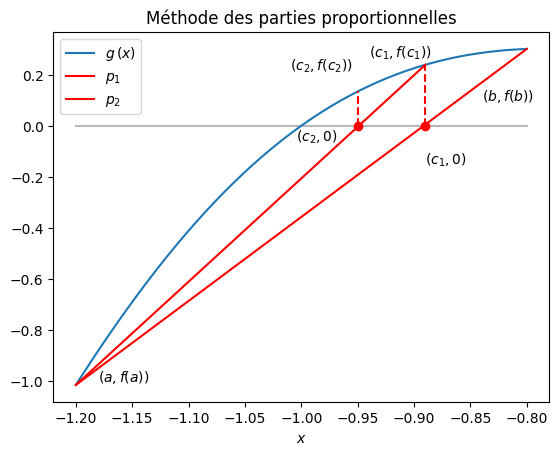

In [246]:
import matplotlib.pyplot as plt
import numpy as np 

def g(x):
    return pow(x,3)*np.sin(np.pi*x)

x = np.linspace(-1.2,-0.8,100)
y = g(x)
plt.plot([x[0],x[-1]], [0,0], c='0.72') # on trace l'axe des x (correspondant à y=0)
#plt.plot([-1.2,-1.2], [y.min(),y.max()], c='0.72') # on utilise les valeurs min et max du tableau y
plt.plot(x,y,label='$g\,(x)$')
plt.plot([x[0],x[-1]],[y[0],y[-1]],'-r', label='$p_1$')
plt.plot([x[0],-0.89],[y[0],g(-0.89)],'-r', label='$p_2$')
plt.plot([-0.89,-0.89], [0, g(-0.89)],'--r')
plt.plot([-0.95,-0.95], [0, g(-0.95)],'--r')
plt.plot(-0.89,0,'ro')
plt.plot(-0.95,0,'ro')
plt.title("Méthode des parties proportionnelles")
plt.xlabel('$x$')
plt.text(-0.89,-0.15,"$(c_1, 0)$")
plt.text(-0.94,0.27,"$(c_1, f(c_1))$")
plt.text(-1.005,-0.06,"$(c_2, 0)$")
plt.text(-1.01,0.22,"$(c_2, f(c_2))$")
plt.text(-1.18,-1.0,"$(a, f(a))$")
plt.text(-0.84,0.1,"$(b, f(b))$")
plt.legend(loc='upper left')
plt.savefig('FigureICS.pdf')
plt.show()

Dans cet exercice, il vous est demandé de déterminer une valeur approchée **du zéro** de la fonction $g(x) = x^3 sin(\pi x)$ étudiée lors de l'exercice 1, dans l'intervalle $]-1.2,-0.8[$ en implémentant cette fois l'algorithme correspondant à la **méthode des parties proportionnelles**. 

1. Déterminez analytiquement l'expression du point $c$ défini précédemment comme l'intersection entre la droite reliant les points $(a, f(a))$ et $(b, f(b))$ et l'axe $y=0$.

2. Implémentez une fonction `resoudre_par_pp` correspondant à la méthode de recherche des zéros par parties proportionnelles. Cette fonction devra admettre en arguments :
    * la fonction `f` pour laquelle nous cherchons à trouver une solution approchée ;
    * les nombres `a` et `b` correspondant aux bornes de l'intervalle initial de recherche ;
    * la tolérance `tol` à atteindre (en abscisse, entre deux éléments successifs) ;
    * le nombre maximal `k_max` d'itérations à effectuer .

    Cette fonction devra retourner la valeur approchée du zéro de $f$ ainsi qu'une liste contenant la valeur $x_k$ obtenue à chaque itération.

3. Vérifiez votre implémentation en considérant une tolérance de $10^{−8}$ et en observant le nombre d'itérations nécessaires.

4. Comparez l'évolution des erreurs absolues obtenues selon la méthode de bissection simple et la méthode des parties proportionnelles. Pour une meilleure visualisation des résultats, on peut représenter le graphe en échelle logarithmique en remplaçant la commande `plot` de `matplotlib` par la  commande `loglog()`, ou `semilogy()`.

#### <font color=grey>Solution </font>

In [247]:
# Solution du point 2

In [248]:
# Solution du point 3


***

## Exercice 4 : Dérivée première d'une fonction 


<font color=grey>**Préambule**

Soit $f:[a,b]\rightarrow \mathcal{R}$ une fonction continûment dérivable dans $[a,b]$, on peut envisager essentiellement trois méthodes (ou schémas) pour approximer la dérivée de $f$ (c'est-à-dire le taux de variation de $f$) en un point $p$ de $]a,b[$. En effet, la définition de la dérivée d'une fonction $f$ suggère qu'une bonne approximation numérique est certainement donnée par
$$
f_{prime,d}(p)=\dfrac{f(p+h)-f(p)}{h}\,,
$$
pour autant que $h$ soit un nombre positif et suffisamment petit.
On appelle cette quantité la **différence finie à droite**. On pourrait également envisager considérer...:
* la **différence finie à gauche**
$$
f_{prime,g}(p)=\dfrac{f(p)-f(p-h)}{h}\,;
$$
* ou la **différence finie centrée** (moyenne des deux autres différences)
$$
f_{prime,c}(p)=\dfrac{f(p+h)-f(p-h)}{2h}\,.
$$</font>

Dans cet exercice, il vous est demandé d'écrire une fonction `derivee` qui admet pour arguments une fonction `f`, un nombre `p`, un schéma `schema` et un nombre `h`. Les deux derniers arguments devront être facultatifs, leur valeur par défaut étant, respectivement, `centree` et `0.1`. La fonction `derivee` devra retourner un nombre correspondant à l'approximation de la dérivée $f'$ de $f$ évaluée en $p$, obtenue à l'aide de la méthode choisie qui pourra être `droite`, `gauche` ou `centree`. La méthode devra retourner un message d'erreur si la méthode passée en arguments n'est pas une des trois méthodes implémentées.

Vérifiez votre travail en représentant la fonction $f(x)=\cos{x}$ au voisinage de $x=0$ et en calculant le nombre dérivé de $f$ en $x=0$ à l'aide des trois schémas proposés. Que pouvez-vous dire de la précision de ces trois schémas ?  
Représentez également sur une même figure la fonction $f(x)=\cos{x}$, la fonction dérivée $f'(x)$ (calculée analytiquement), ainsi que la fonction $f_{prime,c}(x)$. Considérez pour ce faire l'intervalle $[-1,1]$ en abscisse.

#### <font color=grey>Solution </font>

In [249]:
def derivee(f, p, schema= "centree", h= 0.1):
    '''
    :param f: la fonction,
    :param p: un nombre,
    :param schema: 'droite' | 'gauche' | 'centree',
    :param h:  
    '''
    try:
        if h <= 0:
            raise Exception("h n'est pas positif, il faut donner un h plus grand que zéro et suffisamment petit.")
        
        if schema == "gauche":
            return (f(p) - f(p-h))/h
        
        elif schema == "droite":
            return (f(p+h)-f(p))/h
        
        elif schema == "centree":
            return (f(p+h)-f(p-h))/(2*h)
        
        else:
            raise Exception("Le schéma ne fait pas parti de ceux existant")
            
    except Exception as e:
        print(e)
        
        
def f(x):
    return np.cos(x)


derivee(f, 0, h=-1), derivee(f, np.pi, "gauche"), derivee(f, np.pi / 2, "droite")

h n'est pas positif, il faut donner un h plus grand que zéro et suffisamment petit.


(None, np.float64(-0.049958347219742905), np.float64(-0.9983341664682823))